# Pretrain HAT-PAN Fusion on PanCollection WorldView-3

## الداتا التي تأكدنا منها

### WV3 Reduced-Resolution Test

```text
MS:  8 × 64 × 64
PAN: 1 × 256 × 256
GT:  8 × 256 × 256
Scale: ×4
```

### WV3 Training / Validation

```text
MS:  8 × 16 × 16
PAN: 1 × 64 × 64
GT:  8 × 64 × 64
Scale: ×4
```

## استراتيجية النقل إلى داتاك

داتاك تحتوي على 6 Bands، بينما WV3 يحتوي على 8 Bands. لن نحذف Bandين عشوائيًا.

سنفعل:

```text
WV3:
8 MS + 1 PAN → HAT-PAN → 8 MS
                 ↓
تعلم Spatial/Spectral Attention من آلاف العينات
                 ↓
نقل جسم HAT والـAttention إلى موديل داتاك
                 ↓
داتاك:
6 MS + 1 PAN → HAT-PAN → 6 MS
```

عند النقل لاحقًا:

- طبقات Attention وTransformer تُحمّل.
- أول طبقة `9 channels` تُحوّل إلى `7 channels`.
- آخر طبقة `8 channels` تُستبدل بطبقة `6 channels`.
- يتم Fine-tuning على الداتا الخاصة بك.

هذه الـNotebook تنفذ **Pretraining على WV3 فقط**.


## 1) تفعيل GPU

في Colab:

```text
Runtime → Change runtime type → T4 GPU
```


In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("شغّل الـNotebook باستخدام T4 GPU.")

print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2) تثبيت المكتبات وHAT

In [2]:
from pathlib import Path
import shutil
import subprocess
import sys

%cd /content

HAT_REPO = Path("/content/HAT")

if HAT_REPO.exists():
    shutil.rmtree(HAT_REPO)

subprocess.run(
    [
        "git",
        "clone",
        "--depth",
        "1",
        "https://github.com/XPixelGroup/HAT.git",
        str(HAT_REPO),
    ],
    check=True,
)

%cd /content/HAT

!pip install -q -r requirements.txt
!pip install -q -e .
!pip install -q huggingface_hub hf_xet h5py matplotlib tqdm timm

# إصلاح توافق BasicSR مع torchvision الحديثة
!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/' /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py

print("Installation completed.")

/content
/content/HAT
  Preparing metadata (setup.py) ... done
Installation completed.


In [3]:
import numpy as np
import h5py
import torch

print("NumPy:", np.__version__)
print("H5Py:", h5py.__version__)
print("PyTorch:", torch.__version__)

test_array = np.array([1, 2, 3])

print("NumPy test:", test_array.mean())

NumPy: 2.5.1
H5Py: 3.16.0
PyTorch: 2.11.0+cu128
NumPy test: 2.0


## 3) تنزيل وزن HAT ×4 الجاهز

نستخدم وزن RGB كبداية، ثم نكيّفه من `3→3` إلى `9→8`.


In [4]:
from pathlib import Path
import importlib.util

ORIGINAL_ARCH = (
    HAT_REPO
    / "hat"
    / "archs"
    / "hat_arch.py"
)

STANDALONE_ARCH = Path(
    "/content/hat_arch_standalone.py"
)

source = ORIGINAL_ARCH.read_text(
    encoding="utf-8"
)

# استبدال Registry الخاص بـBasicSR بـRegistry بسيط
source = source.replace(
    "from basicsr.utils.registry import ARCH_REGISTRY",
    """
class _SimpleRegistry:
    def register(self):
        def decorator(obj):
            return obj
        return decorator

ARCH_REGISTRY = _SimpleRegistry()
""".strip(),
)

# استخدام نفس الأدوات الرياضية من timm
source = source.replace(
    "from basicsr.archs.arch_util import to_2tuple, trunc_normal_",
    "from timm.layers import to_2tuple, trunc_normal_",
)

STANDALONE_ARCH.write_text(
    source,
    encoding="utf-8"
)

spec = importlib.util.spec_from_file_location(
    "hat_arch_standalone",
    STANDALONE_ARCH,
)

hat_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(hat_module)

HAT = hat_module.HAT

print("HAT imported successfully.")

HAT imported successfully.


## 4) ربط Google Drive ومسارات WV3

In [5]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Super_Resolution_28-07-2026"
)

WV3_DIR = (
    PROJECT_DIR
    / "Public_Datasets"
    / "PanCollection_WV3"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "WV3_HAT_Pretraining"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPO_ID = "elsting/PanCollection"

BEST_MODEL_PATH = (
    OUTPUT_DIR
    / "best_wv3_hat_pan_pretrained.pth"
)

LAST_MODEL_PATH = (
    OUTPUT_DIR
    / "last_wv3_hat_pan_pretrained.pth"
)

HISTORY_PATH = (
    OUTPUT_DIR
    / "wv3_pretraining_history.json"
)

TEST_METRICS_PATH = (
    OUTPUT_DIR
    / "wv3_reduced_test_metrics.json"
)

print("WV3 directory:", WV3_DIR)
print("Output:", OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
WV3 directory: /content/drive/MyDrive/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3
Output: /content/drive/MyDrive/Super_Resolution_28-07-2026/WV3_HAT_Pretraining


## 5) تنزيل WV3 Training وValidation

هذه الخلية تبحث عن جميع ملفات:

```text
training_data/*wv3*.h5
```

وتنزّلها فقط.

قد يكون الحجم عدة جيجابايت.


In [6]:
from huggingface_hub import HfApi, snapshot_download

api = HfApi()

repo_files = api.list_repo_files(
    repo_id=REPO_ID,
    repo_type="dataset",
)

wv3_training_files = [
    file_name
    for file_name in repo_files
    if (
        "wv3" in file_name.lower()
        and "training_data/" in file_name.lower()
        and file_name.lower().endswith(".h5")
    )
]

print("WV3 training/validation files:")

for file_name in wv3_training_files:
    print(" -", file_name)

if not wv3_training_files:
    raise RuntimeError(
        "لم يتم العثور على WV3 training_data files."
    )

snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    allow_patterns=wv3_training_files,
    local_dir=str(WV3_DIR),
)

print("Training/validation download completed.")


WV3 training/validation files:
 - training_data/train_wv3_9714.h5
 - training_data/valid_wv3_9714.h5


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Training/validation download completed.


## 6) اكتشاف ملفات Train وValidation وفحص Shapes

In [7]:
import h5py
import pandas as pd

h5_files = sorted(
    WV3_DIR.rglob("*.h5")
)

train_candidates = [
    path
    for path in h5_files
    if (
        "wv3" in path.name.lower()
        and "train" in path.name.lower()
        and "valid" not in path.name.lower()
        and "test" not in path.name.lower()
    )
]

valid_candidates = [
    path
    for path in h5_files
    if (
        "wv3" in path.name.lower()
        and (
            "valid" in path.name.lower()
            or "validation" in path.name.lower()
        )
    )
]

print("Train candidates:")

for path in train_candidates:
    print(" -", path)

print("\nValidation candidates:")

for path in valid_candidates:
    print(" -", path)

if not train_candidates:
    raise RuntimeError(
        "لم أجد Train H5. أرسل قائمة الملفات المطبوعة."
    )

if not valid_candidates:
    raise RuntimeError(
        "لم أجد Validation H5."
    )

TRAIN_H5 = train_candidates[0]
VALID_H5 = valid_candidates[0]

print("\nSelected Train:", TRAIN_H5)
print("Selected Val  :", VALID_H5)


def inspect_required_keys(path):
    with h5py.File(path, "r") as h5_file:
        rows = []

        for key in ["ms", "pan", "gt", "lms"]:
            if key in h5_file:
                dataset = h5_file[key]

                rows.append({
                    "file": path.name,
                    "key": key,
                    "shape": str(dataset.shape),
                    "dtype": str(dataset.dtype),
                })

    return rows


structure_df = pd.DataFrame(
    inspect_required_keys(TRAIN_H5)
    + inspect_required_keys(VALID_H5)
)

display(structure_df)


Train candidates:
 - /content/drive/MyDrive/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3/training_data/train_wv3_9714.h5

Validation candidates:
 - /content/drive/MyDrive/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3/training_data/valid_wv3_9714.h5

Selected Train: /content/drive/MyDrive/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3/training_data/train_wv3_9714.h5
Selected Val  : /content/drive/MyDrive/Super_Resolution_28-07-2026/Public_Datasets/PanCollection_WV3/training_data/valid_wv3_9714.h5


,file,key,shape,dtype
0,train_wv3_9714.h5,ms,"(9714, 8, 16, 16)",float64
1,train_wv3_9714.h5,pan,"(9714, 1, 64, 64)",float64
2,train_wv3_9714.h5,gt,"(9714, 8, 64, 64)",float64
3,train_wv3_9714.h5,lms,"(9714, 8, 64, 64)",float64
4,valid_wv3_9714.h5,ms,"(1080, 8, 16, 16)",float64
5,valid_wv3_9714.h5,pan,"(1080, 1, 64, 64)",float64
6,valid_wv3_9714.h5,gt,"(1080, 8, 64, 64)",float64
7,valid_wv3_9714.h5,lms,"(1080, 8, 64, 64)",float64


## 7) إعدادات Pretraining

ابدأ بالقيم الحالية للتأكد:

```text
Stage A = 2 epochs
Stage B = 5 epochs
```

بعد نجاح التجربة يمكن زيادتها إلى:

```text
Stage A = 5
Stage B = 20 أو 30
```


In [8]:
import os
import random
import json
import numpy as np

SEED = 42

BATCH_SIZE = 4
ACCUMULATION_STEPS = 2
NUM_WORKERS = 0

STAGE_A_EPOCHS = 2
STAGE_B_EPOCHS = 5

STAGE_A_LR = 1e-4
STAGE_B_LR = 1e-5

WEIGHT_DECAY = 1e-6

SCALE = 4
WV3_MS_BANDS = 8
MAX_DN = 2047.0

USE_AMP = False

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda")

print("Effective batch:", BATCH_SIZE * ACCUMULATION_STEPS)
print("Full float32 training:", not USE_AMP)


Effective batch: 8
Full float32 training: True


## 8) H5 Dataset

نستخدم فقط:

- `ms`
- `pan`
- `gt`

ولا نستخدم `lms` لأننا نُجري Bicubic داخل الموديل.

القيم WV3 في الملفات ضمن نطاق 11-bit تقريبًا، لذلك نقسم على `2047` ونقص القيم إلى `[0,1]`.


In [9]:
from torch.utils.data import Dataset, DataLoader


class WV3H5Dataset(Dataset):
    def __init__(self, h5_path, augment=False):
        self.h5_path = Path(h5_path)
        self.augment = augment

        self._file = None
        self._ms = None
        self._pan = None
        self._gt = None

        with h5py.File(self.h5_path, "r") as h5_file:
            for key in ["ms", "pan", "gt"]:
                if key not in h5_file:
                    raise KeyError(
                        f"{key} not found in {self.h5_path}"
                    )

            self.length = h5_file["ms"].shape[0]

            ms_shape = h5_file["ms"].shape
            pan_shape = h5_file["pan"].shape
            gt_shape = h5_file["gt"].shape

        print(
            self.h5_path.name,
            "samples:",
            self.length,
            "| MS:",
            ms_shape,
            "| PAN:",
            pan_shape,
            "| GT:",
            gt_shape,
        )

    def _ensure_open(self):
        if self._file is None:
            self._file = h5py.File(
                self.h5_path,
                "r",
            )

            self._ms = self._file["ms"]
            self._pan = self._file["pan"]
            self._gt = self._file["gt"]

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        self._ensure_open()

        ms = np.asarray(
            self._ms[index],
            dtype=np.float32,
        )

        pan = np.asarray(
            self._pan[index],
            dtype=np.float32,
        )

        gt = np.asarray(
            self._gt[index],
            dtype=np.float32,
        )

        ms = np.clip(ms / MAX_DN, 0, 1)
        pan = np.clip(pan / MAX_DN, 0, 1)
        gt = np.clip(gt / MAX_DN, 0, 1)

        ms = torch.from_numpy(ms)
        pan = torch.from_numpy(pan)
        gt = torch.from_numpy(gt)

        if self.augment:
            if random.random() < 0.5:
                ms = torch.flip(ms, dims=[2])
                pan = torch.flip(pan, dims=[2])
                gt = torch.flip(gt, dims=[2])

            if random.random() < 0.5:
                ms = torch.flip(ms, dims=[1])
                pan = torch.flip(pan, dims=[1])
                gt = torch.flip(gt, dims=[1])

            rotations = random.randint(0, 3)

            if rotations:
                ms = torch.rot90(
                    ms,
                    rotations,
                    dims=[1, 2],
                )

                pan = torch.rot90(
                    pan,
                    rotations,
                    dims=[1, 2],
                )

                gt = torch.rot90(
                    gt,
                    rotations,
                    dims=[1, 2],
                )

        return {
            "lr_ms": ms.float(),
            "pan": pan.float(),
            "target_ms": gt.float(),
            "index": index,
        }

    def close(self):
        if self._file is not None:
            self._file.close()
            self._file = None


train_dataset = WV3H5Dataset(
    TRAIN_H5,
    augment=True,
)

val_dataset = WV3H5Dataset(
    VALID_H5,
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


train_wv3_9714.h5 samples: 9714 | MS: (9714, 8, 16, 16) | PAN: (9714, 1, 64, 64) | GT: (9714, 8, 64, 64)
valid_wv3_9714.h5 samples: 1080 | MS: (1080, 8, 16, 16) | PAN: (1080, 1, 64, 64) | GT: (1080, 8, 64, 64)
Train batches: 2429
Val batches: 270


## 9) فحص Batch

In [10]:
batch = next(iter(train_loader))

print("MS    :", batch["lr_ms"].shape)
print("PAN   :", batch["pan"].shape)
print("Target:", batch["target_ms"].shape)

print(
    "MS range:",
    float(batch["lr_ms"].min()),
    "→",
    float(batch["lr_ms"].max()),
)

print(
    "PAN range:",
    float(batch["pan"].min()),
    "→",
    float(batch["pan"].max()),
)

assert batch["lr_ms"].shape[1] == 8
assert batch["pan"].shape[1] == 1
assert batch["target_ms"].shape[1] == 8
assert batch["target_ms"].shape[-1] == batch["lr_ms"].shape[-1] * 4


MS    : torch.Size([4, 8, 16, 16])
PAN   : torch.Size([4, 1, 64, 64])
Target: torch.Size([4, 8, 64, 64])
MS range: 0.014689328148961067 → 0.6242340207099915
PAN range: 0.06577843427658081 → 0.8304811716079712


## 10) HAT-PAN Model للـWV3

```text
8 LR-MS + 1 PAN-LR = 9 Channels
HAT ×4 → 8-band residual
Refinement باستخدام PAN الأصلية
Output = 8 Bands
```


In [11]:
import sys
import torch.nn as nn
import torch.nn.functional as F

sys.path.insert(0, str(HAT_REPO))

from hat.archs.hat_arch import HAT


class RefinementBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
        )

    def forward(self, x):
        return x + self.block(x)


class WV3HATPanFusion(nn.Module):
    def __init__(self):
        super().__init__()

        self.hat = HAT(
            upscale=4,
            in_chans=9,
            img_size=16,
            window_size=16,
            compress_ratio=3,
            squeeze_factor=30,
            conv_scale=0.01,
            overlap_ratio=0.5,
            img_range=1.0,
            depths=[6, 6, 6, 6, 6, 6],
            embed_dim=180,
            num_heads=[6, 6, 6, 6, 6, 6],
            mlp_ratio=2,
            upsampler="pixelshuffle",
            resi_connection="1conv",
            use_checkpoint=False,
            drop_path_rate=0.0,
        )

        # HAT default output would be 9 channels.
        self.hat.conv_last = nn.Conv2d(
            64,
            8,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        # Coarse 8 + Bicubic 8 + PAN 1 = 17
        self.refine_head = nn.Conv2d(
            17,
            64,
            3,
            1,
            1,
        )

        self.refine_body = nn.Sequential(
            RefinementBlock(64),
            RefinementBlock(64),
            RefinementBlock(64),
            RefinementBlock(64),
        )

        self.refine_tail = nn.Conv2d(
            64,
            8,
            3,
            1,
            1,
        )

        nn.init.zeros_(self.hat.conv_last.weight)
        nn.init.zeros_(self.hat.conv_last.bias)

        nn.init.zeros_(self.refine_tail.weight)
        nn.init.zeros_(self.refine_tail.bias)

    def forward(self, lr_ms, pan_hr):
        upsampled_ms = F.interpolate(
            lr_ms,
            size=pan_hr.shape[-2:],
            mode="bicubic",
            align_corners=False,
        )

        pan_lr = F.interpolate(
            pan_hr,
            size=lr_ms.shape[-2:],
            mode="area",
        )

        hat_input = torch.cat(
            [lr_ms, pan_lr],
            dim=1,
        )

        hat_residual = self.hat(hat_input)

        coarse_ms = upsampled_ms + hat_residual

        refinement_input = torch.cat(
            [
                coarse_ms,
                upsampled_ms,
                pan_hr,
            ],
            dim=1,
        )

        features = self.refine_head(
            refinement_input
        )

        features = self.refine_body(
            features
        )

        refinement = self.refine_tail(
            features
        )

        return (
            coarse_ms + refinement
        ).clamp(0, 1)


model = WV3HATPanFusion().to(device)

print(
    "Total parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Total parameters: 21,095,008


## 11) تهيئة النموذج من HAT RGB الجاهز

- يتم تحميل كل طبقات HAT المتوافقة.
- `conv_first` تتحول من 3 إلى 9 Channels باستخدام متوسط Kernels.
- `conv_last` جديدة وتُخرج 8 Bands.


In [15]:
!wget -q --show-progress \
  -O "{RGB_WEIGHT_PATH}" \
  "https://huggingface.co/Acly/hat/resolve/main/HAT_SRx4_ImageNet-pretrain.pth"

{RGB_WEIGHT_PATH}   100%[===================>]  81.19M  40.1MB/s    in 2.0s    


In [16]:
print("Weight exists:", RGB_WEIGHT_PATH.exists())

if RGB_WEIGHT_PATH.exists():
    print(
        "Weight size:",
        round(
            RGB_WEIGHT_PATH.stat().st_size / 1024**2,
            2
        ),
        "MB"
    )

NameError: name 'RGB_WEIGHT_PATH' is not defined

In [17]:
from pathlib import Path
import subprocess

# مسار HAT داخل Colab
HAT_REPO = Path("/content/HAT")

# مسار فولدر الأوزان
WEIGHT_DIR = (
    HAT_REPO
    / "experiments"
    / "pretrained_models"
)

WEIGHT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# تعريف المتغير الذي كان ناقصًا
RGB_WEIGHT_PATH = (
    WEIGHT_DIR
    / "HAT_SRx4_ImageNet-pretrain.pth"
)

# تنزيل الوزن إذا لم يكن موجودًا
if not RGB_WEIGHT_PATH.exists():

    print("Downloading pretrained HAT weight...")

    url = (
        "https://huggingface.co/Acly/hat/resolve/main/"
        "HAT_SRx4_ImageNet-pretrain.pth"
    )

    subprocess.run(
        [
            "wget",
            "-q",
            "--show-progress",
            "-O",
            str(RGB_WEIGHT_PATH),
            url,
        ],
        check=True,
    )

# التحقق النهائي
print("Weight path  :", RGB_WEIGHT_PATH)
print("Weight exists:", RGB_WEIGHT_PATH.exists())

if RGB_WEIGHT_PATH.exists():
    print(
        "Weight size:",
        round(
            RGB_WEIGHT_PATH.stat().st_size
            / 1024**2,
            2,
        ),
        "MB",
    )
else:
    raise FileNotFoundError(
        "فشل تنزيل ملف وزن HAT."
    )

Weight path  : /content/HAT/experiments/pretrained_models/HAT_SRx4_ImageNet-pretrain.pth
Weight exists: True
Weight size: 81.19 MB


In [18]:
rgb_checkpoint = torch.load(
    RGB_WEIGHT_PATH,
    map_location="cpu",
)

rgb_pretrained = (
    rgb_checkpoint["params_ema"]
    if "params_ema" in rgb_checkpoint
    else rgb_checkpoint["params"]
)

current_state = model.hat.state_dict()

matched = {}

for key, value in rgb_pretrained.items():
    if (
        key in current_state
        and current_state[key].shape == value.shape
        and key not in {
            "conv_first.weight",
            "conv_first.bias",
        }
        and not key.startswith("conv_last")
    ):
        matched[key] = value

load_result = model.hat.load_state_dict(
    matched,
    strict=False,
)

with torch.no_grad():
    rgb_first_weight = rgb_pretrained[
        "conv_first.weight"
    ]

    rgb_first_bias = rgb_pretrained[
        "conv_first.bias"
    ]

    average_kernel = rgb_first_weight.mean(
        dim=1,
        keepdim=True,
    )

    expanded_kernel = average_kernel.repeat(
        1,
        9,
        1,
        1,
    ) * (3.0 / 9.0)

    model.hat.conv_first.weight.copy_(
        expanded_kernel
    )

    model.hat.conv_first.bias.copy_(
        rgb_first_bias
    )

print("Matched pretrained tensors:", len(matched))
print("Missing:", len(load_result.missing_keys))
print("Unexpected:", len(load_result.unexpected_keys))


Matched pretrained tensors: 860
Missing: 4
Unexpected: 0


## 12) Numerical Safety Check

In [19]:
debug_batch = next(iter(train_loader))

debug_ms = debug_batch["lr_ms"][:1].to(device)
debug_pan = debug_batch["pan"][:1].to(device)
debug_target = debug_batch["target_ms"][:1].to(device)

model.eval()

with torch.inference_mode():
    debug_prediction = model(
        debug_ms,
        debug_pan,
    )

print(
    "Prediction shape:",
    debug_prediction.shape,
)

print(
    "Finite:",
    torch.isfinite(debug_prediction).all().item(),
)

print(
    "Range:",
    float(debug_prediction.min()),
    "→",
    float(debug_prediction.max()),
)

assert debug_prediction.shape == debug_target.shape
assert torch.isfinite(debug_prediction).all()


Prediction shape: torch.Size([1, 8, 64, 64])
Finite: True
Range: 0.041125863790512085 → 0.5885036587715149


## 13) Metrics

In [20]:
import math


def batch_psnr(prediction, target):
    mse = torch.mean(
        (prediction - target) ** 2,
        dim=(1, 2, 3),
    )

    return (
        10
        * torch.log10(
            1.0
            / torch.clamp(mse, min=1e-12)
        )
    ).mean()


def batch_sam_degrees(prediction, target):
    dot = torch.sum(
        prediction * target,
        dim=1,
    )

    pred_norm = torch.linalg.vector_norm(
        prediction,
        dim=1,
    )

    target_norm = torch.linalg.vector_norm(
        target,
        dim=1,
    )

    cosine = dot / torch.clamp(
        pred_norm * target_norm,
        min=1e-8,
    )

    cosine = torch.clamp(
        cosine,
        -1 + 1e-7,
        1 - 1e-7,
    )

    return (
        torch.acos(cosine)
        * (180.0 / math.pi)
    ).mean()


## 14) Stage Configuration

In [21]:
def freeze_hat(model):
    for parameter in model.hat.parameters():
        parameter.requires_grad = False


def configure_stage_a(model):
    freeze_hat(model)

    for module in [
        model.hat.conv_last,
        model.refine_head,
        model.refine_body,
        model.refine_tail,
    ]:
        for parameter in module.parameters():
            parameter.requires_grad = True


def configure_stage_b(model):
    freeze_hat(model)

    for layer in model.hat.layers[-2:]:
        for parameter in layer.parameters():
            parameter.requires_grad = True

    for module in [
        model.hat.norm,
        model.hat.conv_after_body,
        model.hat.conv_before_upsample,
        model.hat.upsample,
        model.hat.conv_last,
        model.refine_head,
        model.refine_body,
        model.refine_tail,
    ]:
        for parameter in module.parameters():
            parameter.requires_grad = True


def count_trainable(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


## 15) Training Functions

التدريب يتم بـFloat32 لمنع مشاكل NaN التي ظهرت سابقًا.


In [22]:
from tqdm.auto import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.L1Loss()


def create_optimizer(model, learning_rate):
    return AdamW(
        [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ],
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    freeze_hat_body=False,
):
    model.train()

    if freeze_hat_body:
        model.hat.eval()
        model.hat.conv_last.train()

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    total_psnr = 0.0
    total_samples = 0

    progress = tqdm(
        loader,
        desc="Train",
        leave=False,
    )

    for batch_index, batch in enumerate(
        progress,
        start=1,
    ):
        lr_ms = batch["lr_ms"].to(
            device,
            non_blocking=True,
        )

        pan = batch["pan"].to(
            device,
            non_blocking=True,
        )

        target = batch["target_ms"].to(
            device,
            non_blocking=True,
        )

        prediction = model(lr_ms, pan)

        if not torch.isfinite(prediction).all():
            raise FloatingPointError(
                f"Non-finite output at batch {batch_index}"
            )

        loss = criterion(
            prediction,
            target,
        )

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f"Non-finite loss at batch {batch_index}"
            )

        (
            loss / ACCUMULATION_STEPS
        ).backward()

        should_step = (
            batch_index % ACCUMULATION_STEPS == 0
            or batch_index == len(loader)
        )

        if should_step:
            for name, parameter in model.named_parameters():
                if (
                    parameter.requires_grad
                    and parameter.grad is not None
                    and not torch.isfinite(
                        parameter.grad
                    ).all()
                ):
                    raise FloatingPointError(
                        f"Non-finite gradient in {name}"
                    )

            torch.nn.utils.clip_grad_norm_(
                [
                    parameter
                    for parameter in model.parameters()
                    if parameter.requires_grad
                ],
                max_norm=1.0,
            )

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        batch_size = lr_ms.shape[0]

        total_loss += loss.item() * batch_size

        total_psnr += (
            batch_psnr(
                prediction.detach(),
                target,
            ).item()
            * batch_size
        )

        total_samples += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return {
        "loss": total_loss / total_samples,
        "psnr_db": total_psnr / total_samples,
    }


@torch.inference_mode()
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    total_psnr = 0.0
    total_sam = 0.0
    total_samples = 0

    for batch in tqdm(
        loader,
        desc="Validation",
        leave=False,
    ):
        lr_ms = batch["lr_ms"].to(
            device,
            non_blocking=True,
        )

        pan = batch["pan"].to(
            device,
            non_blocking=True,
        )

        target = batch["target_ms"].to(
            device,
            non_blocking=True,
        )

        prediction = model(lr_ms, pan)

        if not torch.isfinite(prediction).all():
            raise FloatingPointError(
                "Non-finite validation prediction."
            )

        loss = criterion(
            prediction,
            target,
        )

        batch_size = lr_ms.shape[0]

        total_loss += loss.item() * batch_size

        total_psnr += (
            batch_psnr(
                prediction,
                target,
            ).item()
            * batch_size
        )

        total_sam += (
            batch_sam_degrees(
                prediction,
                target,
            ).item()
            * batch_size
        )

        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "psnr_db": total_psnr / total_samples,
        "sam_degrees": total_sam / total_samples,
    }


def train_stage(
    stage_name,
    epochs,
    learning_rate,
    history,
    best_val_loss,
):
    optimizer = create_optimizer(
        model,
        learning_rate,
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    print("\n" + "=" * 70)
    print(stage_name)
    print(
        "Trainable parameters:",
        f"{count_trainable(model):,}"
    )
    print("=" * 70)

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            freeze_hat_body=(
                stage_name == "Stage A"
            ),
        )

        val_metrics = evaluate_model(
            model,
            val_loader,
        )

        scheduler.step(
            val_metrics["loss"]
        )

        record = {
            "stage": stage_name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_psnr_db": train_metrics["psnr_db"],
            "val_loss": val_metrics["loss"],
            "val_psnr_db": val_metrics["psnr_db"],
            "val_sam_degrees": val_metrics["sam_degrees"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }

        history.append(record)

        print(
            f"{stage_name} | "
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train L1 {train_metrics['loss']:.5f} | "
            f"Val L1 {val_metrics['loss']:.5f} | "
            f"Val PSNR {val_metrics['psnr_db']:.3f} dB | "
            f"Val SAM {val_metrics['sam_degrees']:.3f}°"
        )

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "stage": stage_name,
            "epoch": epoch,
            "val_metrics": val_metrics,
            "architecture": {
                "sensor": "WorldView-3",
                "ms_bands": 8,
                "hat_input_channels": 9,
                "hat_output_channels": 8,
                "scale": 4,
            },
        }

        torch.save(
            checkpoint,
            LAST_MODEL_PATH,
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]

            torch.save(
                checkpoint,
                BEST_MODEL_PATH,
            )

            print("Saved new best model.")

    return history, best_val_loss


## 16) تشغيل Stage A

In [23]:
for path in [
    BEST_MODEL_PATH,
    LAST_MODEL_PATH,
    HISTORY_PATH,
]:
    if path.exists():
        path.unlink()
        print("Deleted stale file:", path)

configure_stage_a(model)

history = []
best_val_loss = float("inf")

history, best_val_loss = train_stage(
    stage_name="Stage A",
    epochs=STAGE_A_EPOCHS,
    learning_rate=STAGE_A_LR,
    history=history,
    best_val_loss=best_val_loss,
)



Stage A
Trainable parameters: 314,512


Train:   0%|          | 0/2429 [00:00<?, ?it/s]

Validation:   0%|          | 0/270 [00:00<?, ?it/s]

Stage A | Epoch 01/2 | Train L1 0.01907 | Val L1 0.01801 | Val PSNR 31.526 dB | Val SAM 5.513°
Saved new best model.


Train:   0%|          | 0/2429 [00:00<?, ?it/s]

Validation:   0%|          | 0/270 [00:00<?, ?it/s]

Stage A | Epoch 02/2 | Train L1 0.01727 | Val L1 0.01684 | Val PSNR 32.073 dB | Val SAM 5.202°
Saved new best model.


## 17) تشغيل Stage B

In [24]:
stage_a_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)

model.load_state_dict(
    stage_a_checkpoint["model_state_dict"]
)

configure_stage_b(model)

history, best_val_loss = train_stage(
    stage_name="Stage B",
    epochs=STAGE_B_EPOCHS,
    learning_rate=STAGE_B_LR,
    history=history,
    best_val_loss=best_val_loss,
)

with open(
    HISTORY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        history,
        file,
        indent=2,
        ensure_ascii=False,
    )

print("Best WV3 model:", BEST_MODEL_PATH)
print("History:", HISTORY_PATH)



Stage B
Trainable parameters: 7,697,176


Train:   0%|          | 0/2429 [00:00<?, ?it/s]

Validation:   0%|          | 0/270 [00:00<?, ?it/s]

Stage B | Epoch 01/5 | Train L1 0.01633 | Val L1 0.01644 | Val PSNR 32.311 dB | Val SAM 5.079°
Saved new best model.


Train:   0%|          | 0/2429 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/270 [00:00<?, ?it/s]

Stage B | Epoch 04/5 | Train L1 0.01592 | Val L1 0.01608 | Val PSNR 32.518 dB | Val SAM 4.960°


Train:   0%|          | 0/2429 [00:00<?, ?it/s]

Validation:   0%|          | 0/270 [00:00<?, ?it/s]

Stage B | Epoch 05/5 | Train L1 0.01583 | Val L1 0.01603 | Val PSNR 32.568 dB | Val SAM 4.944°
Saved new best model.
Best WV3 model: /content/drive/MyDrive/Super_Resolution_28-07-2026/WV3_HAT_Pretraining/best_wv3_hat_pan_pretrained.pth
History: /content/drive/MyDrive/Super_Resolution_28-07-2026/WV3_HAT_Pretraining/wv3_pretraining_history.json


## 18) منحنيات التدريب

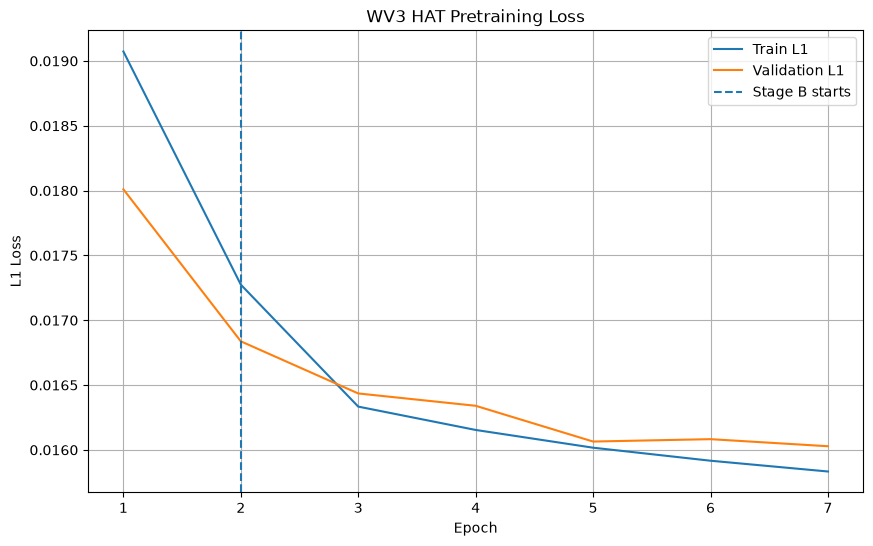

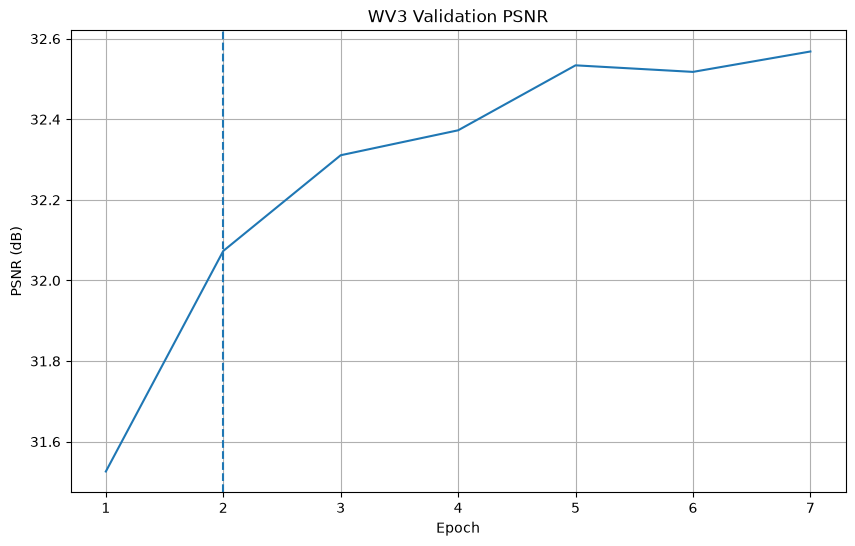

In [25]:
import matplotlib.pyplot as plt

epochs = list(
    range(1, len(history) + 1)
)

train_loss = [
    item["train_loss"]
    for item in history
]

val_loss = [
    item["val_loss"]
    for item in history
]

val_psnr = [
    item["val_psnr_db"]
    for item in history
]

plt.figure(figsize=(10, 6))
plt.plot(
    epochs,
    train_loss,
    label="Train L1",
)

plt.plot(
    epochs,
    val_loss,
    label="Validation L1",
)

plt.axvline(
    STAGE_A_EPOCHS,
    linestyle="--",
    label="Stage B starts",
)

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("WV3 HAT Pretraining Loss")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(
    epochs,
    val_psnr,
)

plt.axvline(
    STAGE_A_EPOCHS,
    linestyle="--",
)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("WV3 Validation PSNR")
plt.grid()
plt.show()


## 19) عرض نتيجة Validation

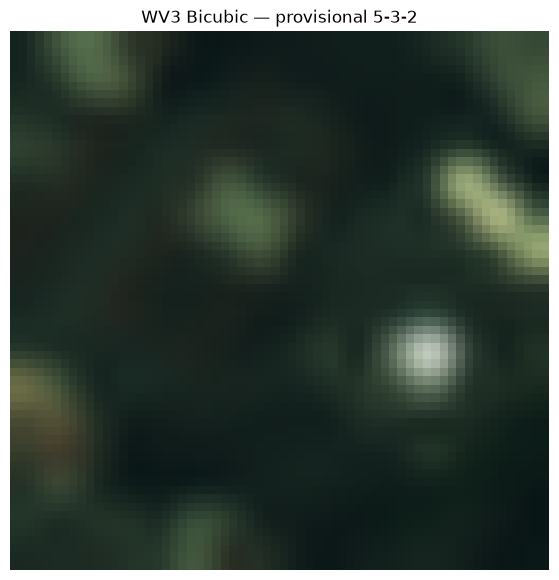

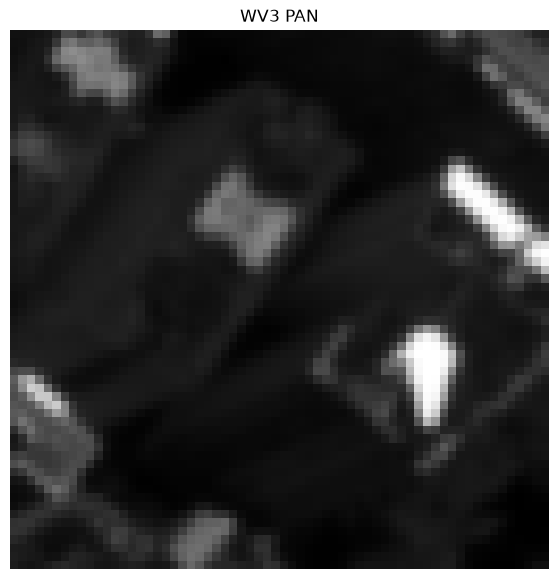

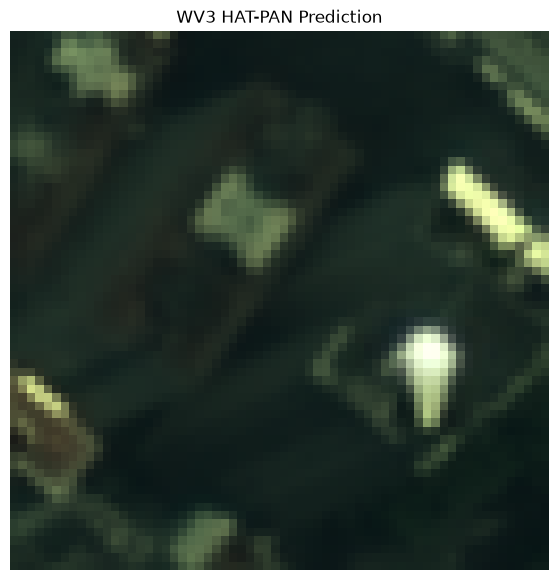

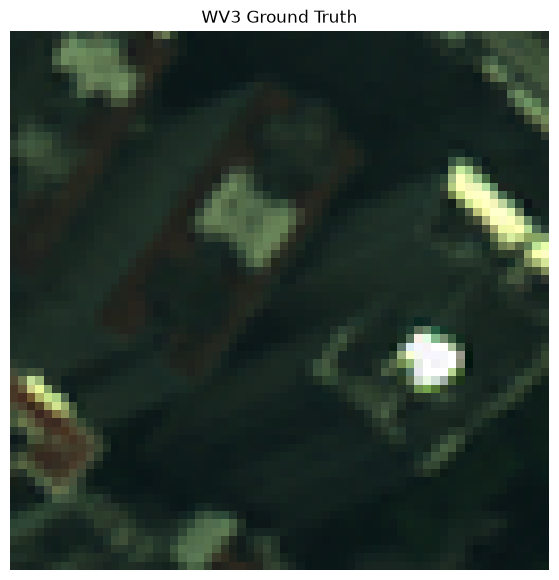

Prediction finite: True


In [26]:
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.eval()

validation_batch = next(
    iter(val_loader)
)

lr_ms = validation_batch["lr_ms"][:1].to(device)
pan = validation_batch["pan"][:1].to(device)
target = validation_batch["target_ms"][:1].to(device)

with torch.inference_mode():
    prediction = model(
        lr_ms,
        pan,
    )

bicubic = F.interpolate(
    lr_ms,
    size=target.shape[-2:],
    mode="bicubic",
    align_corners=False,
).clamp(0, 1)


def provisional_rgb_532(tensor):
    # WV3 provisional natural-color assumption:
    # 1-indexed Bands 5,3,2 → zero-indexed 4,2,1
    return torch.stack(
        [
            tensor[4],
            tensor[2],
            tensor[1],
        ],
        dim=-1,
    ).clamp(0, 1).cpu().numpy()


plt.figure(figsize=(7, 7))
plt.imshow(
    provisional_rgb_532(
        bicubic[0]
    )
)
plt.title("WV3 Bicubic — provisional 5-3-2")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(
    pan[0, 0].cpu().numpy(),
    cmap="gray",
)
plt.title("WV3 PAN")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(
    provisional_rgb_532(
        prediction[0]
    )
)
plt.title("WV3 HAT-PAN Prediction")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(
    provisional_rgb_532(
        target[0]
    )
)
plt.title("WV3 Ground Truth")
plt.axis("off")
plt.show()

print(
    "Prediction finite:",
    torch.isfinite(
        prediction
    ).all().item()
)


# المطلوب بعد التشغيل

أرسل:

1. أسماء Train وValidation المختارة.
2. عدد Samples في كل ملف.
3. نتائج Stage A وStage B.
4. أفضل Validation PSNR وSAM.
5. صور Prediction وGround Truth.

بعد نجاح Pretraining، سنبني Notebook منفصلة تنقل الوزن:

```text
WV3 HAT-PAN 9→8
        ↓ transfer
Your HAT-PAN 7→6
        ↓ fine-tune
Your Dataset
```

ثم نقارن:

```text
Fusion CNN
HAT من ImageNet فقط
HAT بعد WV3 Pretraining
```
